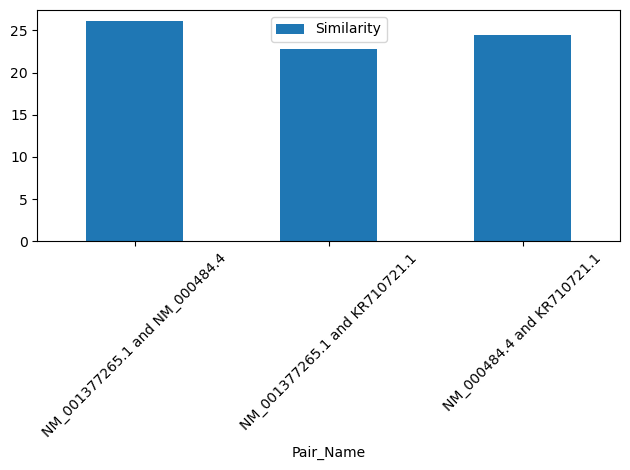

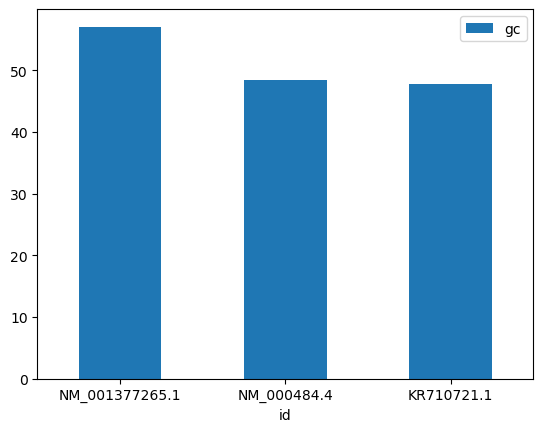

               id  length         gc  \
0  NM_001377265.1    6815  57.094644   
1     NM_000484.4    3583  48.506838   
2      KR710721.1     873  47.880871   

                                            sequence  
0  (G, C, A, G, T, C, A, C, C, G, C, C, A, C, C, ...  
1  (G, T, C, A, G, T, T, T, C, C, T, C, G, G, C, ...  
2  (G, T, T, C, G, T, T, G, C, A, A, C, A, A, A, ...  
The biggest Guanine Cytosine percentages has a percentage of 57.09464416727806% with the gene responsable for that being NM_001377265.1


In [12]:
from Bio import SeqIO
import matplotlib.pyplot as plt
import pandas as pd
Similarity=[]

i=0
def full_analysis(sequence):
    seq = sequence
    genes=[]
    for record in SeqIO.parse(sequence, "fasta"):
       
        gen = {
            "id": record.id,
            "length": len(record.seq),
            "gc": (record.seq.count('G') + record.seq.count('C')) / len(record.seq) * 100,
            "sequence": record.seq
        }
        genes.append(gen)
    return genes
genes = full_analysis("brain_genes.fasta")    
def find_highest_gc(genes):
    highest_gc=0
    id_of_greater_GC=""
    for x in genes:
        if x["gc"]>=highest_gc:
            highest_gc=x["gc"]
            id_of_greater_GC=x["id"]

    print(f"The biggest Guanine Cytosine percentages has a percentage of {highest_gc}% with the gene responsable for that being {id_of_greater_GC}")

  
def fasta_to_dataframe(genes):
    gdf=pd.DataFrame(genes)
    gdf.sort_values("length", ascending=False)
    gdf.plot.bar(x='id', y='gc', rot=0)
    
    plt.show()
    print(gdf)
    return gdf

        
def gene_comparator(seq1, seq2) :
    matches=0
    for charl, char2 in zip(seq1, seq2):
        if charl == char2:
            matches=matches+1
    return matches/min(len(seq1), len(seq2))*100
    
for i in range(len(genes)):
    for j in range(i + 1, len(genes)):
        matches = gene_comparator(
            genes[i]["sequence"],
            genes[j]["sequence"]
        )
        similarity={
          "Pair_Name": f"{genes[i]["id"]} and {genes[j]["id"]}",
          "Similarity":round(matches, 1)
        }
        Similarity.append(similarity)  # dentro del loop
        
sdf=pd.DataFrame(Similarity)
sdf.sort_values("Similarity", ascending=False)
sdf.plot.bar(x='Pair_Name', y='Similarity', rot=45)
plt.axhline(y=promedio, color='red', linestyle='--', label='Average')
plt.tight_layout()
plt.show()






genes=full_analysis("brain_genes.fasta")
fasta_to_dataframe(genes)
find_highest_gc(genes)

In [9]:
def generate_report(genes):
    print(f" {'Id':<15}{'Length in Bases':<20}{'GC':<35}")
    print("-----------------------------------------------------")
    for i in range(0, len(genes)):
        if i==0:
            print(f"{genes[i]['id']:<20}{genes[i]['length']:<15}{genes[i]['gc']:<25.1f}")
            diferencia_de_gc=0
            diferencia_de_tamaño=0
        elif i != 0:
            diferencia_de_gc= genes[i-1]["gc"]-genes[i]["gc"]
            diferencia_de_tamaño=genes[i-1]["length"]-genes[i]["length"]
           
            print(f" Diferencia entre la sequencia anterior y la siguiente en cuanto a tamaño son {diferencia_de_tamaño} bases y en cuanto a Guanina Cytosina en {diferencia_de_gc:.2f} por ciento")
            print(f"{genes[i]['id']:<20}{genes[i]['length']:<15}{genes[i]['gc']:<25.1f}")
            